In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('/content/apple.webp')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [3]:
h, w = image.shape[:2]

In [4]:
#Translation
tx = 100
ty = 130

M_translation = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(
    image,
    M_translation,
    (w, h)
)

In [5]:
#Scaling
sx2 = 3.5
sy2 = 5.5
scaled = cv2.resize(
    image,
    None,
    fx = sx2,
    fy = sy2
)

In [6]:
#Rotation
center = (w // 2, h // 2)
angle = 45

M_rotation = cv2.getRotationMatrix2D(
    center,
    angle,
    1.0
)
rotated = cv2.warpAffine(
    image,
    M_rotation,
    (w, h)
)

In [7]:
#Reflectin
reflected_x = cv2.flip(image, 0)
reflected_y = cv2.flip(image, 1)
reflected_xy = cv2.flip(image, -1)
combine_scaled = cv2.resize(
    image,
    None,
    fx = sx2,
    fy = sy2,
)
h2, w2 = scaled.shape[:2]
center2 = (w2 // 2, h2 //2)
M_rotation = cv2.getRotationMatrix2D(
    center,
    30,
    1.0
)
combine_rotated = cv2.warpAffine(
    combine_scaled,
    M_rotation,
    (w2, h2)
)
combine_reflection = cv2.flip(combine_rotated, -1)
tx2 = 50
ty2 = 30
M_translation = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])
combined_final = cv2.warpAffine(
    combine_reflection,
    M_translation,
    (w2 + tx2, h2 + ty2)
)

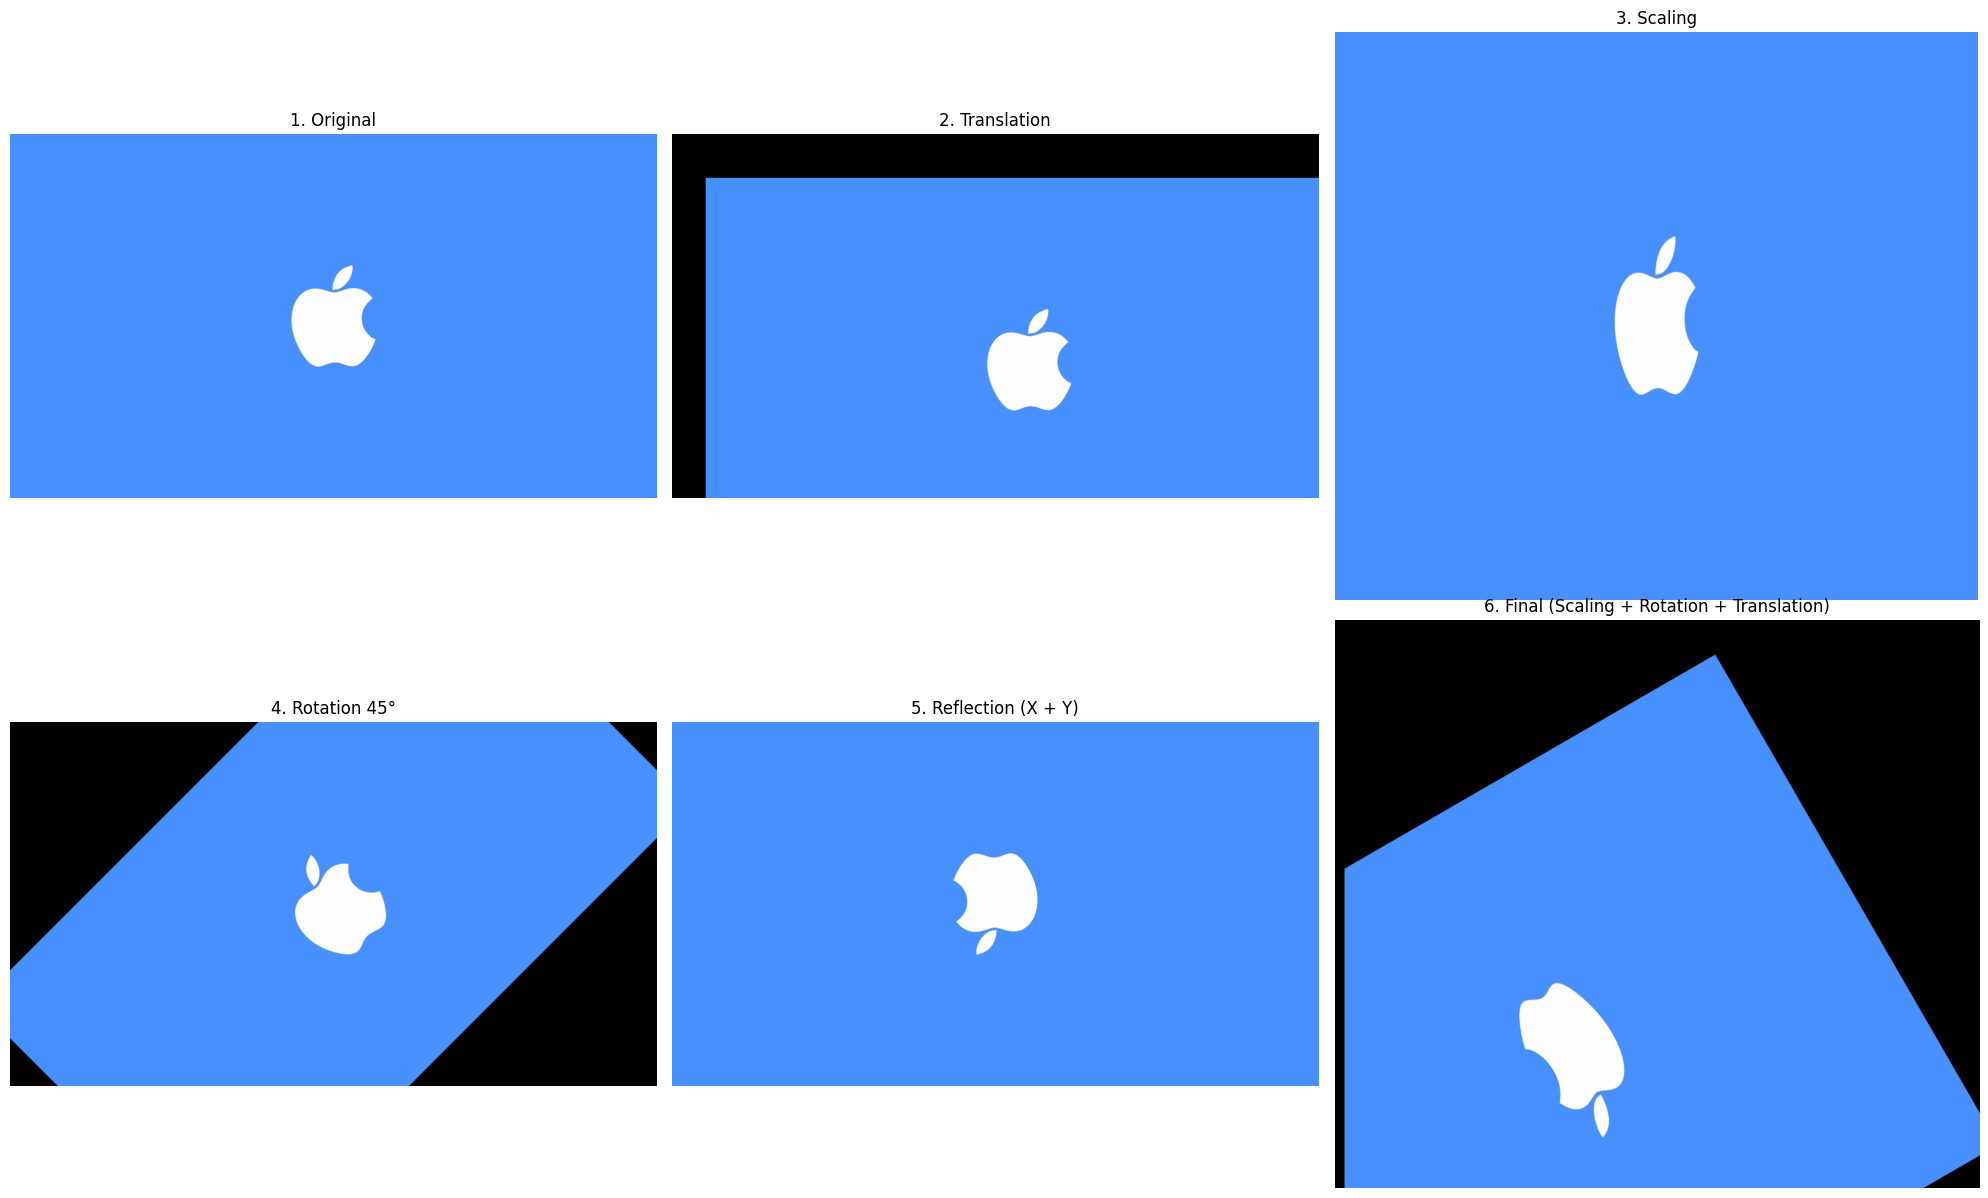

In [8]:
titles = [
    "1. Original",
    "2. Translation",
    "3. Scaling",
    "4. Rotation 45°",
    "5. Reflection (X + Y)",
    "6. Final (Scaling + Rotation + Translation)"
]

images = [
    image,
    translated,
    scaled,
    rotated,
    reflected_xy,
    combined_final
]

plt.figure(figsize=(20, 12))
for i, (title, img) in enumerate (
    zip(titles, images),
    start=1
):
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(title, fontsize=12)
    plt.axis("off")
plt.tight_layout()
plt.show()